In [86]:
import numpy as np
import matplotlib.pyplot as plt 

In [87]:
omega   = 1/15
theta   = 0.56   # ← cambiar
eta     = 0.03
gamma   = 0.019  # ← cambiar
delta_t = 1/100



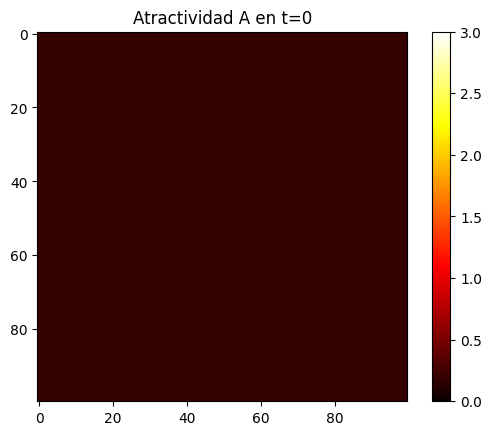

0.19293333333333337


In [88]:
N = 100

l=1

b_bar = theta*gamma/omega

# Inicamos las matrices Ao del atractivo estático de cada celda y B como el atractivo dinámico

Ao = np.ones((N,N)) * (1/30)

B = np.full((N,N),b_bar)

# El atractivo total de cada celda:

A = Ao + B

n_bar = np.zeros((N,N))

for i, j in range(N,N):

    n_bar[i,j] = gamma*delta_t/(1-np.exp(-A[i,j]*delta_t))

n = n_bar

plt.imshow(A, cmap='hot',vmin=0, vmax=3)
plt.colorbar()
plt.title(f'Atractividad A en t={0}')
plt.show()

print(np.mean(A))

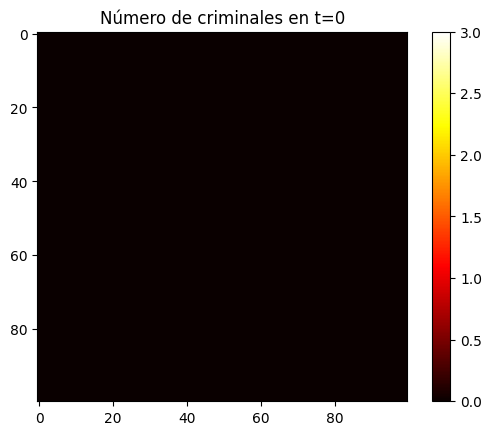

In [89]:
plt.imshow(n, cmap='hot',vmin=0, vmax=3)
plt.colorbar()
plt.title(f'Número de criminales en t={0}')
plt.show()

In [90]:
# Actualiza B

def update_B_vN(B, n, omega, eta, theta):
    # Vecindad de von Neumann (4 vecinos)

    z = 4

    # Defines la suma del atractivo dinámico de los vecinos (efecto ventana rota)

    neighbors = (np.roll(B, 1, axis=0) + np.roll(B, -1, axis=0) +
                 np.roll(B, 1, axis=1) + np.roll(B, -1, axis=1))
    
    E = n  # crímenes ocurridos (por ahora aproximamos con n)
    
    B_new = ((1 - eta) * B + (eta / z) * neighbors) * (1 - omega) + theta*E
    return B_new

In [91]:
def update_B_Moore(B, n, omega, eta, theta, delta_t):
    z = 8  # 8 vecinos en Moore
    neighbors = (np.roll(B, 1, axis=0) + np.roll(B, -1, axis=0) +
                 np.roll(B, 1, axis=1) + np.roll(B, -1, axis=1) +
                 np.roll(np.roll(B, 1, axis=0), 1, axis=1) +   # diagonal superior izquierda
                 np.roll(np.roll(B, 1, axis=0), -1, axis=1) +  # diagonal superior derecha
                 np.roll(np.roll(B, -1, axis=0), 1, axis=1) +  # diagonal inferior izquierda
                 np.roll(np.roll(B, -1, axis=0), -1, axis=1))  # diagonal inferior derecha
    
    E = n
    B_new = ((1 - eta) * B + (eta / z) * neighbors) * (1 - omega*delta_t) + theta*E*delta_t
    return B_new

In [92]:
B = update_B_vN(B, n, omega, eta, theta)
print(B.round(2))

[[0.15 0.15 0.15 ... 0.15 0.15 0.15]
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]
 ...
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]
 [0.15 0.15 0.15 ... 0.15 0.15 0.15]]


In [93]:
def update_A(A0, B):
    return A0 + B

In [94]:
def update_criminals_vN(n, A, gamma):
    n_new = np.zeros((N, N), dtype=int)
    E = np.zeros((N, N), dtype=int)  # crímenes ocurridos
    
    for i in range(N):
        for j in range(N):
            for _ in range(n[i, j]):
                p = 1 - np.exp(-A[i, j])
                if np.random.random() < p:
                    # Comete crimen y desaparece
                    E[i, j] += 1
                else:
                    # Se mueve a un vecino sesgado por atractividad
                    neighbors = [(i-1)%N, (i+1)%N, (i)%N, (i)%N]
                    neighbors_j = [(j)%N, (j)%N, (j-1)%N, (j+1)%N]
                    weights = [A[ni, nj] for ni, nj in zip(neighbors, neighbors_j)]
                    weights = np.array(weights) / sum(weights)
                    idx = np.random.choice(4, p=weights)
                    n_new[neighbors[idx], neighbors_j[idx]] += 1
    
    # Generar nuevos criminales a tasa gamma
    new_criminals = np.random.poisson(gamma, size=(N, N))
    n_new += new_criminals
    
    return n_new, E

In [95]:
def update_criminals_Moore(n, A, gamma, delta_t):
    n = n.astype(int)  # Fix: reasignar
    n_new = np.zeros((N, N), dtype=int)
    E = np.zeros((N, N), dtype=int)
    for i in range(N):
        for j in range(N):
            for _ in range(n[i, j]):
                p = 1 - np.exp(-A[i, j] * delta_t)
                if np.random.random() < p:
                    E[i, j] += 1
                else:
                    neighbors_i = [(i-1)%N, (i+1)%N, i,      i,
                                   (i-1)%N, (i-1)%N, (i+1)%N, (i+1)%N]
                    neighbors_j = [j,      j,       (j-1)%N, (j+1)%N,
                                   (j-1)%N, (j+1)%N, (j-1)%N, (j+1)%N]
                    weights = [A[ni, nj] for ni, nj in zip(neighbors_i, neighbors_j)]
                    weights = np.array(weights) / sum(weights)
                    idx = np.random.choice(8, p=weights)
                    n_new[neighbors_i[idx], neighbors_j[idx]] += 1
    new_criminals = np.random.poisson(gamma * delta_t, size=(N, N)).astype(int)
    n_new += new_criminals
    return n_new, E

In [ ]:
print(A.round(2))
#aa

[[0.19 0.19 0.19 ... 0.19 0.19 0.19]
 [0.19 0.19 0.19 ... 0.19 0.19 0.19]
 [0.19 0.19 0.19 ... 0.19 0.19 0.19]
 ...
 [0.19 0.19 0.19 ... 0.19 0.19 0.19]
 [0.19 0.19 0.19 ... 0.19 0.19 0.19]
 [0.19 0.19 0.19 ... 0.19 0.19 0.19]]


In [97]:
T = 10000  # número de pasos

for t in range(T):
    # 1. Mover criminales y registrar crímenes
    #n, E = update_criminals_vN(n, A, gamma)
    n, E = update_criminals_Moore(n, A, gamma, delta_t)

    # 2. Actualizar B con los crímenes ocurridos
    #B = update_B_vN(B, E, omega, eta)
    B = update_B_Moore(B, E, omega, eta, theta, delta_t)

    # 3. Actualizar A
    A = update_A(Ao, B)

KeyboardInterrupt: 

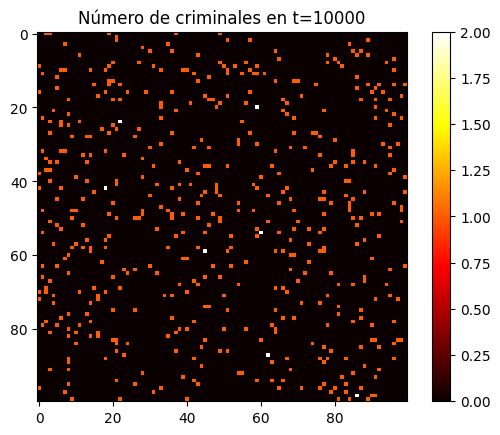

In [ ]:
plt.imshow(n, cmap='hot',vmin=n.min(), vmax=n.max())
plt.colorbar()
plt.title(f'Número de criminales en t={T}')
plt.show()

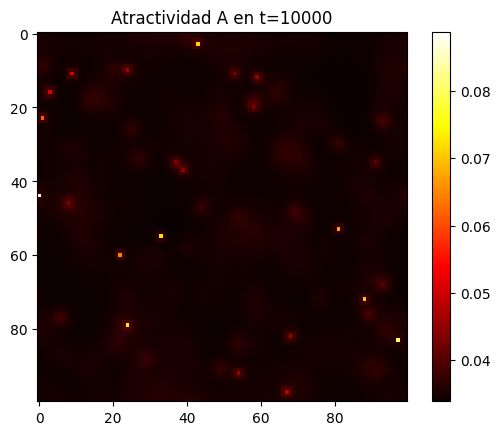

In [ ]:
plt.imshow(A, cmap='hot',vmin=A.min(), vmax=A.max())
plt.colorbar()
plt.title(f'Atractividad A en t={T}')
plt.show()

In [98]:
def update_B_vN(B, E, omega, eta, theta, delta_t):
    z = 4
    neighbors_sum = (np.roll(B, 1, axis=0) + np.roll(B, -1, axis=0) +
                     np.roll(B, 1, axis=1) + np.roll(B, -1, axis=1))
    lap_B = (neighbors_sum - z * B) / (l**2)
    B_new = (B + eta * l**2 / z * lap_B) * (1 - omega * delta_t) + theta * delta_t * E
    return np.maximum(B_new, 0.0)

def update_criminals_vN(n, A, gamma, delta_t):
    n = n.astype(int)
    n_new = np.zeros((N, N), dtype=int)
    E     = np.zeros((N, N), dtype=int)
    for i in range(N):
        for j in range(N):
            for _ in range(n[i, j]):
                p = 1 - np.exp(-A[i, j] * delta_t)
                if np.random.random() < p:
                    E[i, j] += 1
                else:
                    neighbors_i = [(i-1)%N, (i+1)%N, i,        i      ]
                    neighbors_j = [j,        j,       (j-1)%N, (j+1)%N]
                    weights = np.array([A[ni, nj] for ni, nj in zip(neighbors_i, neighbors_j)])
                    weights /= weights.sum()
                    idx = np.random.choice(4, p=weights)
                    n_new[neighbors_i[idx], neighbors_j[idx]] += 1
    new_criminals = np.random.poisson(gamma * delta_t, size=(N, N)).astype(int)
    n_new += new_criminals
    return n_new, E

In [100]:
import matplotlib.animation as animation

N = 100

l=1

b_bar = theta*gamma/omega

# Inicamos las matrices Ao del atractivo estático de cada celda y B como el atractivo dinámico

Ao = np.ones((N,N)) * (1/30)

B = np.full((N,N),b_bar)

# El atractivo total de cada celda:

A = Ao + B

n_bar = np.zeros((N,N))

for i in range(N):
    for j in range(N):

        n_bar[i,j] = gamma*delta_t/(1-np.exp(-A[i,j]*delta_t))

n = n_bar


# Guardar frames
frames = []
fig, ax = plt.subplots()
im = ax.imshow(A, cmap='hot', vmin=0, animated=True)
plt.colorbar(im)

for t in range(10000):
    n, E = update_criminals_vN(n, A, gamma, delta_t)
    B = update_B_vN(B, E, omega, eta, theta, delta_t)
    A = update_A(Ao, B)
    
    if t % 5 == 0:  # guarda un frame cada 5 pasos
        im = ax.imshow(A, cmap='hot', animated=True)
        ax.set_title(f't={t}')
        frames.append([im])

ani = animation.ArtistAnimation(fig, frames, interval=100, blit=True)
ani.save('hotspots.gif', writer='pillow')
plt.close()
print("GIF guardado")

GIF guardado


In [ ]:
print(n.sum())

498


Equilibrio: B_bar=0.1596, A_bar=0.1929, n_bar=0.0986
Criminales totales esperados: 1615.0
Criminales iniciales: 1615

Simulando 73000 pasos (730 días)...
Usando función vectorizada rápida

  t=10 días — criminales: 2037, A_mean: 0.1159, A_max: 0.1220
  t=365 días — criminales: 9011, A_mean: 0.0349, A_max: 0.0437


/var/folders/7s/ngx3lkxx51519gv_3vqgqvmm0000gn/T/ipykernel_3369/1327259090.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


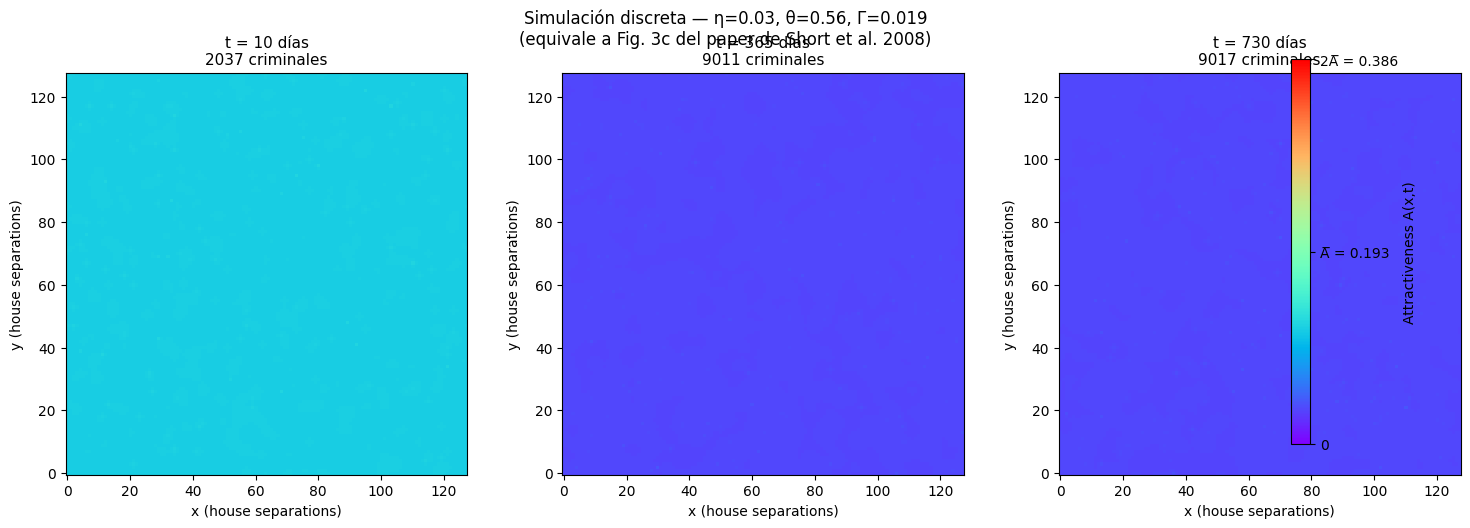


Guardado: crime_hotspots.png

--- Diagnóstico ---
B_bar teórico:  0.15960
A_bar teórico:  0.19293
n_bar teórico:  0.09857
B_mean final:   0.00157
A_mean final:   0.03490
n_mean final:   0.55035
A_max/A_bar:    0.23x  (hotspots deben ser >>1)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# =============================================================================
# Parámetros del paper (Fig. 3c: stationary hotspots)
# =============================================================================
N      = 128        # grid 128x128 como en el paper
l      = 1.0        # espaciado de la grilla (house separations)
dt     = 1/100      # paso de tiempo (días) — CRÍTICO: faltaba en el código original
omega  = 1/15       # tasa de decaimiento del atractivo dinámico (días^-1)
A0_val = 1/30       # atractivo estático uniforme (días^-1)
eta    = 0.03       # parámetro de neighborhood effects — Fig. 3c
theta  = 0.56       # aumento de atractivo por crimen — Fig. 3c
Gamma  = 0.019      # tasa de generación de criminales por celda — Fig. 3c
z      = 4          # vecinos de Von Neumann (el paper usa z=4 para cuadrada)

# Para Fig. 3d (dynamic hotspots): eta=0.03, theta=5.6, Gamma=0.002
# Para Fig. 3a (homogeneous):      eta=0.2,  theta=0.56, Gamma=0.019
# Para Fig. 3b (dynamic hotspots): eta=0.2,  theta=5.6,  Gamma=0.002

# =============================================================================
# Valores de equilibrio homogéneo (Ec. 2.10 del paper)
# B_bar = theta * Gamma / omega
# n_bar = Gamma * dt / (1 - exp(-A_bar * dt))
# =============================================================================
B_bar = theta * Gamma / omega
A_bar = A0_val + B_bar
n_bar = Gamma * dt / (1 - np.exp(-A_bar * dt))

print(f"Equilibrio: B_bar={B_bar:.4f}, A_bar={A_bar:.4f}, n_bar={n_bar:.4f}")
print(f"Criminales totales esperados: {n_bar * N**2:.1f}")

# =============================================================================
# Inicialización en equilibrio homogéneo (como dice el paper)
# =============================================================================
Ao = np.ones((N, N)) * A0_val
B  = np.ones((N, N)) * B_bar          # FIX: inicializar en B_bar, no en 0
A  = Ao + B

# Número de criminales: Poisson con media n_bar por celda
rng = np.random.default_rng(42)
n   = rng.poisson(lam=n_bar, size=(N, N)).astype(int)

print(f"Criminales iniciales: {n.sum()}")

# =============================================================================
# Función de actualización de B (Ec. 2.6 del paper)
# B_s(t+dt) = [B_s + (eta*l^2/z) * LapB] * (1 - omega*dt) + theta*dt * E_s
#
# FIXES:
#   - (1 - omega*dt) en vez de (1 - omega)
#   - theta*dt*E en vez de theta*E   [porque theta*dt = epsilon del paper]
#   - Laplaciano correcto con l^2 en denominador
# =============================================================================
def update_B(B, E, omega, eta, theta, dt, l, z):
    # Laplaciano discreto (Ec. 2.7): suma vecinos - z*B_s, dividido l^2
    # Con condiciones de contorno periódicas
    neighbors_sum = (
        np.roll(B, 1, axis=0) + np.roll(B, -1, axis=0) +
        np.roll(B, 1, axis=1) + np.roll(B, -1, axis=1)
    )
    lap_B = (neighbors_sum - z * B) / (l**2)

    B_new = (B + eta * l**2 / z * lap_B) * (1 - omega * dt) + theta * dt * E
    return np.maximum(B_new, 0.0)   # B no puede ser negativo

# =============================================================================
# Función de actualización de criminales (Ec. 2.2, 2.3 del paper)
# Con vecinos de Von Neumann (z=4, como en el paper para grilla cuadrada)
# =============================================================================
def update_criminals(n, A, Gamma, dt, N):
    n_new = np.zeros((N, N), dtype=int)
    E     = np.zeros((N, N), dtype=int)

    # Precomputar probabilidades de burglary
    p = 1.0 - np.exp(-A * dt)   # FIX: multiplicar por dt

    # Índices de los 4 vecinos de Von Neumann (periódicos)
    di = [-1, 1, 0, 0]
    dj = [ 0, 0,-1, 1]

    for i in range(N):
        for j in range(N):
            num = n[i, j]
            if num == 0:
                continue
            pij = p[i, j]

            # Crímenes: binomial(num, pij)
            crimes = rng.binomial(num, pij)
            E[i, j] += crimes
            movers  = num - crimes

            # Los que se mueven: biased random walk hacia vecinos
            if movers > 0:
                ni_list = [(i + di[k]) % N for k in range(4)]
                nj_list = [(j + dj[k]) % N for k in range(4)]
                weights = np.array([A[ni_list[k], nj_list[k]] for k in range(4)])
                w_sum   = weights.sum()
                if w_sum > 0:
                    weights /= w_sum
                else:
                    weights = np.ones(4) / 4.0

                chosen = rng.choice(4, size=movers, p=weights)
                for k in chosen:
                    n_new[ni_list[k], nj_list[k]] += 1

    # Generar nuevos criminales (Poisson con tasa Gamma por celda por paso)
    new_criminals = rng.poisson(Gamma * dt, size=(N, N)).astype(int)
    n_new += new_criminals
    return n_new, E

# =============================================================================
# Versión vectorizada (más rápida) para el movimiento de criminales
# Aproximación: válida cuando n_bar es pequeño (la mayoría de celdas tiene ≤1)
# =============================================================================
def update_criminals_fast(n, A, Gamma, dt, N, rng):
    p = 1.0 - np.exp(-A * dt)

    # Crímenes
    crimes = rng.binomial(n, p)
    E      = crimes.copy()

    # Los que se mueven
    movers_count = n - crimes

    # Para cada celda, cada movedor elige un vecino proporcional a A
    # Aproximación vectorizada: distribuir movers usando proporciones
    A_up    = np.roll(A, 1, axis=0)
    A_down  = np.roll(A, -1, axis=0)
    A_left  = np.roll(A, 1, axis=1)
    A_right = np.roll(A, -1, axis=1)
    A_total = A_up + A_down + A_left + A_right
    A_total = np.where(A_total == 0, 1.0, A_total)

    # Fracción esperada de movers hacia cada dirección
    f_up    = A_up    / A_total
    f_down  = A_down  / A_total
    f_left  = A_left  / A_total
    f_right = A_right / A_total

    # Mover criminales según fracciones (redondeando con multinomial)
    # Para eficiencia, usamos floor + distribución del resto
    m = movers_count.astype(float)
    n_up    = (m * f_up).astype(int)
    n_down  = (m * f_down).astype(int)
    n_left  = (m * f_left).astype(int)
    n_right = m.astype(int) - n_up - n_down - n_left

    n_new  = np.zeros((N, N), dtype=int)
    n_new += np.roll(n_up,    -1, axis=0)   # los que van "arriba" llegan a fila-1
    n_new += np.roll(n_down,   1, axis=0)
    n_new += np.roll(n_left,  -1, axis=1)
    n_new += np.roll(n_right,  1, axis=1)

    # Nuevos criminales
    new_criminals = rng.poisson(Gamma * dt, size=(N, N)).astype(int)
    n_new += new_criminals

    return n_new, E

# =============================================================================
# Simulación principal
# =============================================================================
T_days    = 730      # días totales a simular
steps_per_day = int(1 / dt)
T         = T_days * steps_per_day   # pasos totales
save_at   = {10, 365, 730}           # días en los que guardar snapshot
snapshots  = {}

print(f"\nSimulando {T} pasos ({T_days} días)...")
print(f"Usando función vectorizada rápida\n")

for t in range(T):
    n, E = update_criminals_fast(n, A, Gamma, dt, N, rng)
    B    = update_B(B, E, omega, eta, theta, dt, l, z)
    A    = Ao + B

    day = int(t * dt)   # día actual
    if day in save_at and day not in snapshots:
        snapshots[day] = {
            'A': A.copy(),
            'n_total': n.sum()
        }
        print(f"  t={day} días — criminales: {n.sum()}, A_mean: {A.mean():.4f}, A_max: {A.max():.4f}")

# Guardar t=730 si no se guardó (último paso)
if 730 not in snapshots:
    snapshots[730] = {'A': A.copy(), 'n_total': n.sum()}

# =============================================================================
# Visualización — mismo estilo de colores que el paper
# =============================================================================
# El paper usa: verde = B_bar (equilibrio), violeta = 0, rojo = ≥ 2*B_bar
# Normalizamos A relativo a A_bar

fig, axes = plt.subplots(1, len(snapshots), figsize=(5 * len(snapshots), 5))
if len(snapshots) == 1:
    axes = [axes]

cmap = plt.cm.rainbow   # igual que el paper (violeta → verde → rojo)

for ax, (day, snap) in zip(axes, sorted(snapshots.items())):
    A_snap  = snap['A']
    A_norm  = A_snap / (2 * A_bar)   # 0 = violeta, 0.5 = verde (equilibrio), 1 = rojo
    im = ax.imshow(A_norm, cmap=cmap, vmin=0, vmax=1,
                   origin='lower', interpolation='nearest')
    ax.set_title(f't = {day} días\n{snap["n_total"]} criminales', fontsize=11)
    ax.set_xlabel('x (house separations)')
    ax.set_ylabel('y (house separations)')

# Colorbar con etiquetas en unidades físicas
cbar = fig.colorbar(im, ax=axes, fraction=0.03, pad=0.04)
cbar.set_ticks([0, 0.5, 1.0])
cbar.set_ticklabels(['0', f'A̅ = {A_bar:.3f}', f'2A̅ = {2*A_bar:.3f}'])
cbar.set_label('Attractiveness A(x,t)', fontsize=10)

fig.suptitle(
    f'Simulación discreta — η={eta}, θ={theta}, Γ={Gamma}\n'
    f'(equivale a Fig. 3c del paper de Short et al. 2008)',
    fontsize=12
)
plt.tight_layout()
plt.savefig('hotspots.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGuardado: crime_hotspots.png")

# =============================================================================
# Diagnóstico: comparar con equilibrio teórico
# =============================================================================
print("\n--- Diagnóstico ---")
print(f"B_bar teórico:  {B_bar:.5f}")
print(f"A_bar teórico:  {A_bar:.5f}")
print(f"n_bar teórico:  {n_bar:.5f}")
print(f"B_mean final:   {B.mean():.5f}")
print(f"A_mean final:   {A.mean():.5f}")
print(f"n_mean final:   {n.mean():.5f}")
print(f"A_max/A_bar:    {A.max()/A_bar:.2f}x  (hotspots deben ser >>1)")